In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [1]:
print("hello")

hello


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [8]:
df = pd.read_csv("online_retail.csv")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [9]:
print("Shape:", df.shape)

df.info()

Shape: (541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [11]:
df.isnull().sum()
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns

summary = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Standard Deviation": df[numeric_cols].std(),
    "Q1": df[numeric_cols].quantile(0.25),
    "Q2 (Median)": df[numeric_cols].quantile(0.50),
    "Q3": df[numeric_cols].quantile(0.75)
})

summary

,Mean,Median,Standard Deviation,Q1,Q2 (Median),Q3
Quantity,9.552250,3.00,218.081158,1.00,3.00,10.00
UnitPrice,4.611114,2.08,96.759853,1.25,2.08,4.13
CustomerID,15287.690570,15152.00,1713.600303,13953.00,15152.00,16791.00


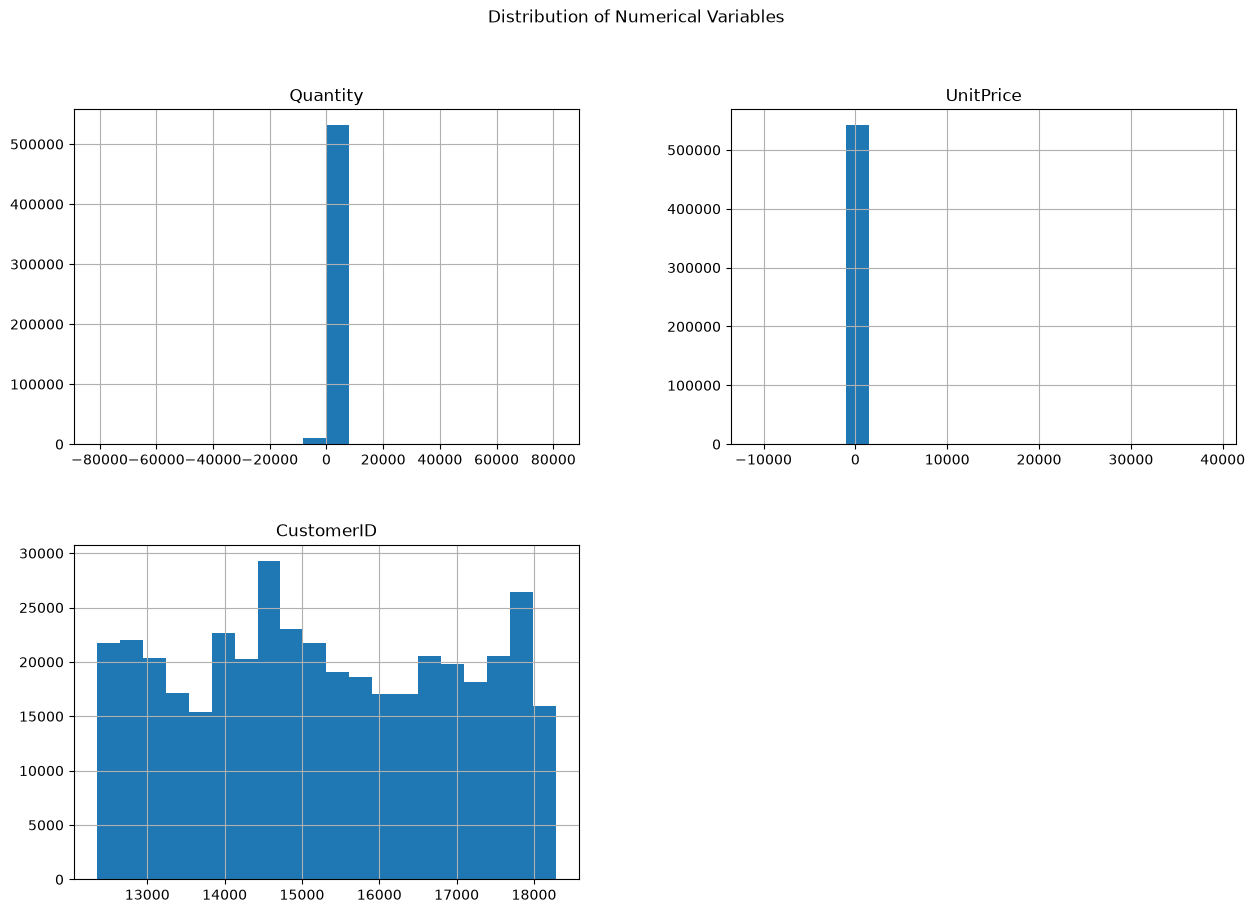

In [13]:
df[numeric_cols].hist(
    figsize=(15, 10),
    bins=20
)

plt.suptitle("Distribution of Numerical Variables")
plt.show()

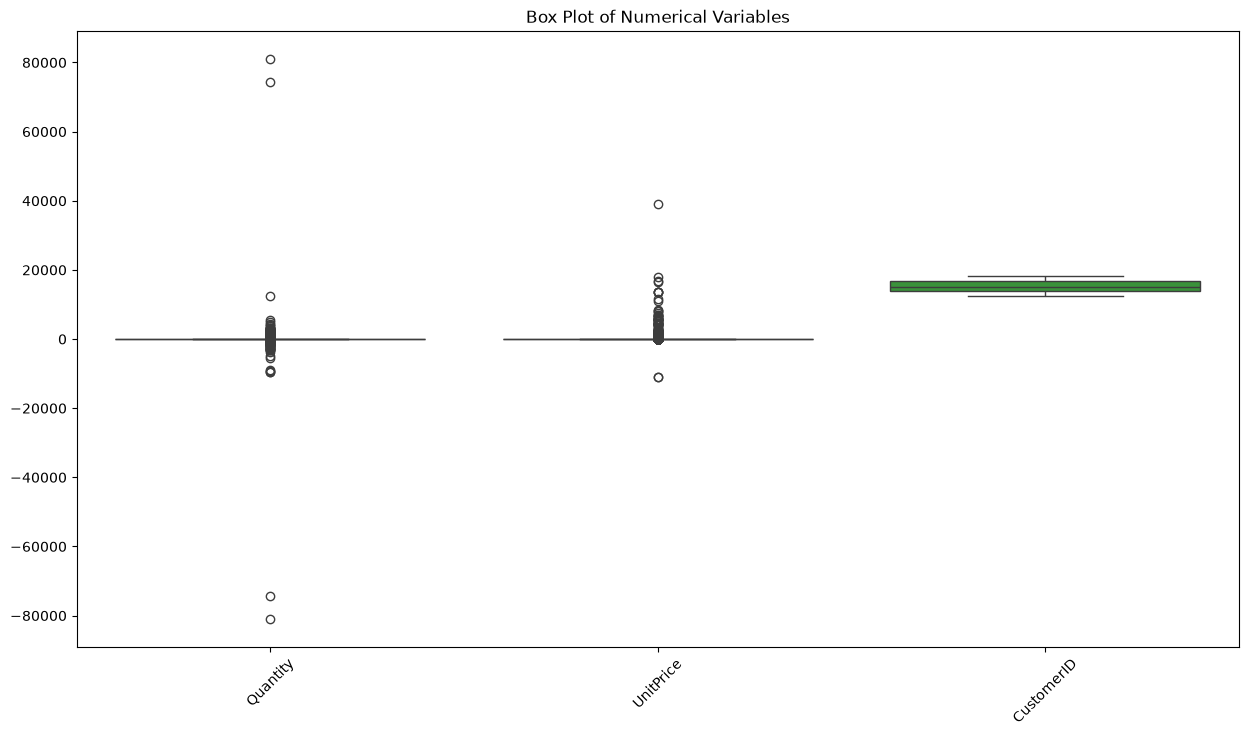

In [14]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)
plt.title("Box Plot of Numerical Variables")
plt.show()

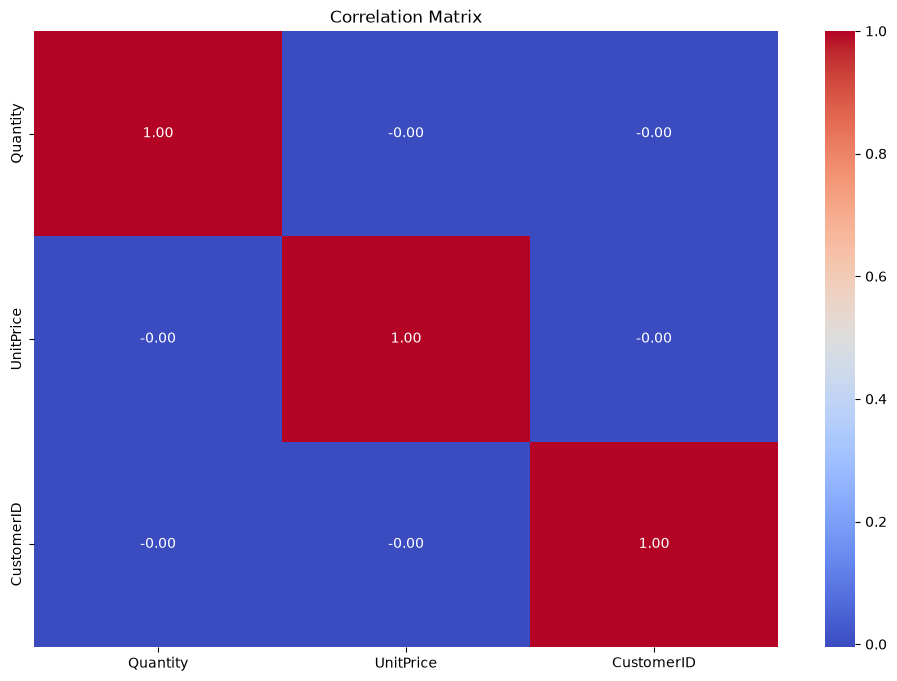

In [15]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

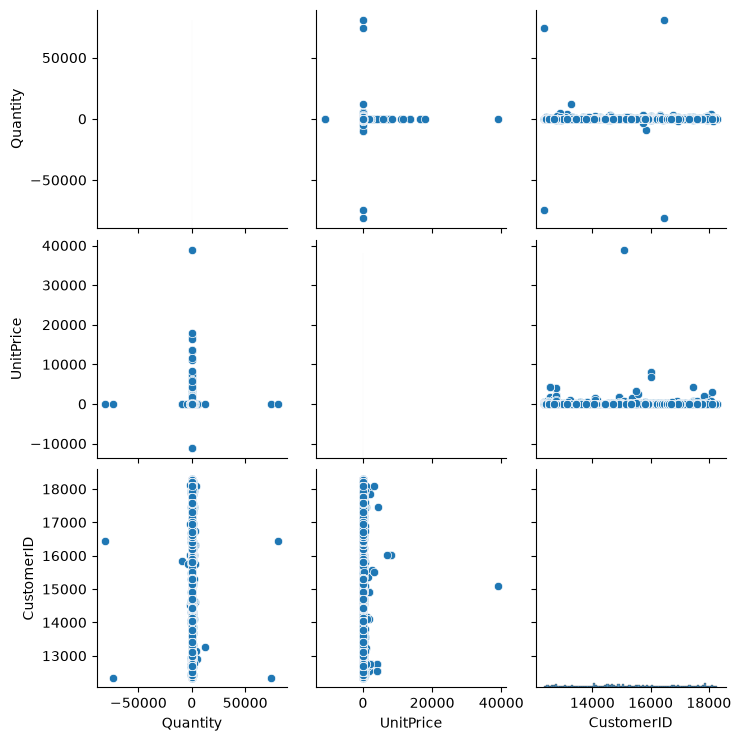

In [17]:
sns.pairplot(df[numeric_cols])
plt.show()

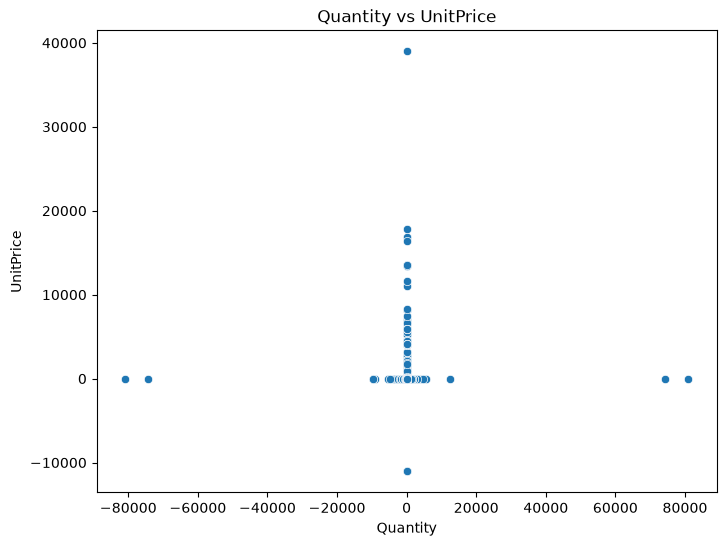

In [18]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=numeric_cols[0],
    y=numeric_cols[1]
)

plt.title(f"{numeric_cols[0]} vs {numeric_cols[1]}")
plt.show()